<a href="https://colab.research.google.com/github/riquetz06/Ciencia-de-datos/blob/main/MLG_LOGMSFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#En jupyter
pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn

In [2]:
#En google colab
pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

In [4]:
from google.colab import files

uploaded = files.upload()

Saving retornos_logaritmicos_combinados.csv to retornos_logaritmicos_combinados.csv


In [5]:
df = pd.read_csv("retornos_logaritmicos_combinados.csv")

In [6]:
print(df.head())

         Date  MSFT_Log_Returns  ^DJI_Log_Returns  ^GSPC_Log_Returns
0  11/08/2025         -0.000517         -0.004549          -0.002507
1  12/08/2025          0.014215          0.010935           0.011282
2  13/08/2025         -0.016498          0.010375           0.003225
3  14/08/2025          0.003643         -0.000245           0.000303
4  15/08/2025         -0.004431          0.000776          -0.002901


In [7]:
print(df.shape)

(250, 4)


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               250 non-null    object 
 1   MSFT_Log_Returns   250 non-null    float64
 2   ^DJI_Log_Returns   250 non-null    float64
 3   ^GSPC_Log_Returns  250 non-null    float64
dtypes: float64(3), object(1)
memory usage: 7.9+ KB
None


In [9]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

In [10]:
print(df.dtypes)

Date                 datetime64[ns]
MSFT_Log_Returns            float64
^DJI_Log_Returns            float64
^GSPC_Log_Returns           float64
dtype: object


In [12]:
print(df.isnull().sum())

Date                 0
MSFT_Log_Returns     0
^DJI_Log_Returns     0
^GSPC_Log_Returns    0
dtype: int64


In [13]:
print(df.isna().sum())

Date                 0
MSFT_Log_Returns     0
^DJI_Log_Returns     0
^GSPC_Log_Returns    0
dtype: int64


In [14]:
print(df.isna().sum())

Date                 0
MSFT_Log_Returns     0
^DJI_Log_Returns     0
^GSPC_Log_Returns    0
dtype: int64


In [15]:
print(
    df[
        [
            "MSFT_Log_Returns",
            "^DJI_Log_Returns",
            "^GSPC_Log_Returns"
        ]
    ].describe()
)

       MSFT_Log_Returns  ^DJI_Log_Returns  ^GSPC_Log_Returns
count        250.000000        250.000000         250.000000
mean          -0.000141          0.000806           0.000776
std            0.020026          0.007966           0.008122
min           -0.105284         -0.022105          -0.027486
25%           -0.010879         -0.003774          -0.003658
50%           -0.000231          0.001009           0.001100
75%            0.009112          0.005506           0.005792
max            0.144159          0.028056           0.028715


In [16]:
variables = [
    "MSFT_Log_Returns",
    "^DJI_Log_Returns",
    "^GSPC_Log_Returns"
]

for var in variables:

    print("\nVariable:", var)

    print("Asimetría:",
          df[var].skew())

    print("Curtosis:",
          df[var].kurtosis())


Variable: MSFT_Log_Returns
Asimetría: 0.9967179299003049
Curtosis: 13.033439682013395

Variable: ^DJI_Log_Returns
Asimetría: 0.05019719202863069
Curtosis: 0.7988852908350133

Variable: ^GSPC_Log_Returns
Asimetría: -0.2580586716521048
Curtosis: 1.2099597045194783


In [17]:
for var in variables:

    jb = stats.jarque_bera(df[var])

    print("\n", var)
    print("Jarque-Bera:", jb.statistic)
    print("p-value:", jb.pvalue)


 MSFT_Log_Returns
Jarque-Bera: 1734.3424861850724
p-value: 0.0

 ^DJI_Log_Returns
Jarque-Bera: 6.106037013193181
p-value: 0.04721618670116633

 ^GSPC_Log_Returns
Jarque-Bera: 16.806339067828805
p-value: 0.00022415572787864714


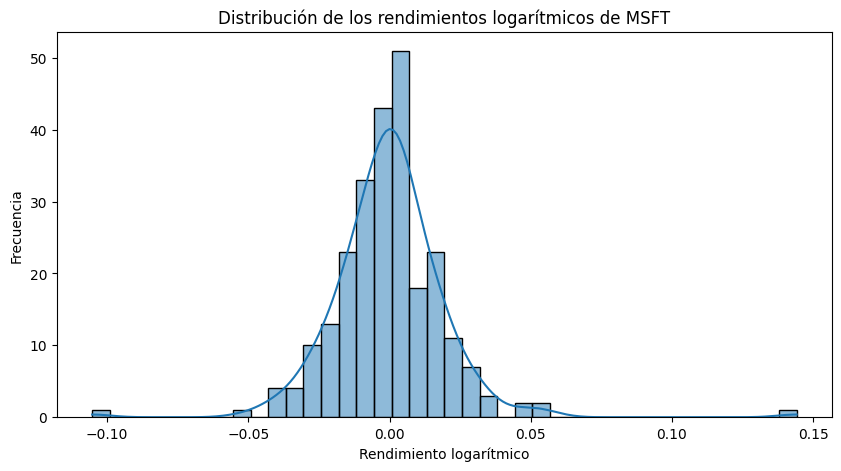

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["MSFT_Log_Returns"],
    kde=True
)

plt.title("Distribución de los rendimientos logarítmicos de MSFT")
plt.xlabel("Rendimiento logarítmico")
plt.ylabel("Frecuencia")

plt.show()

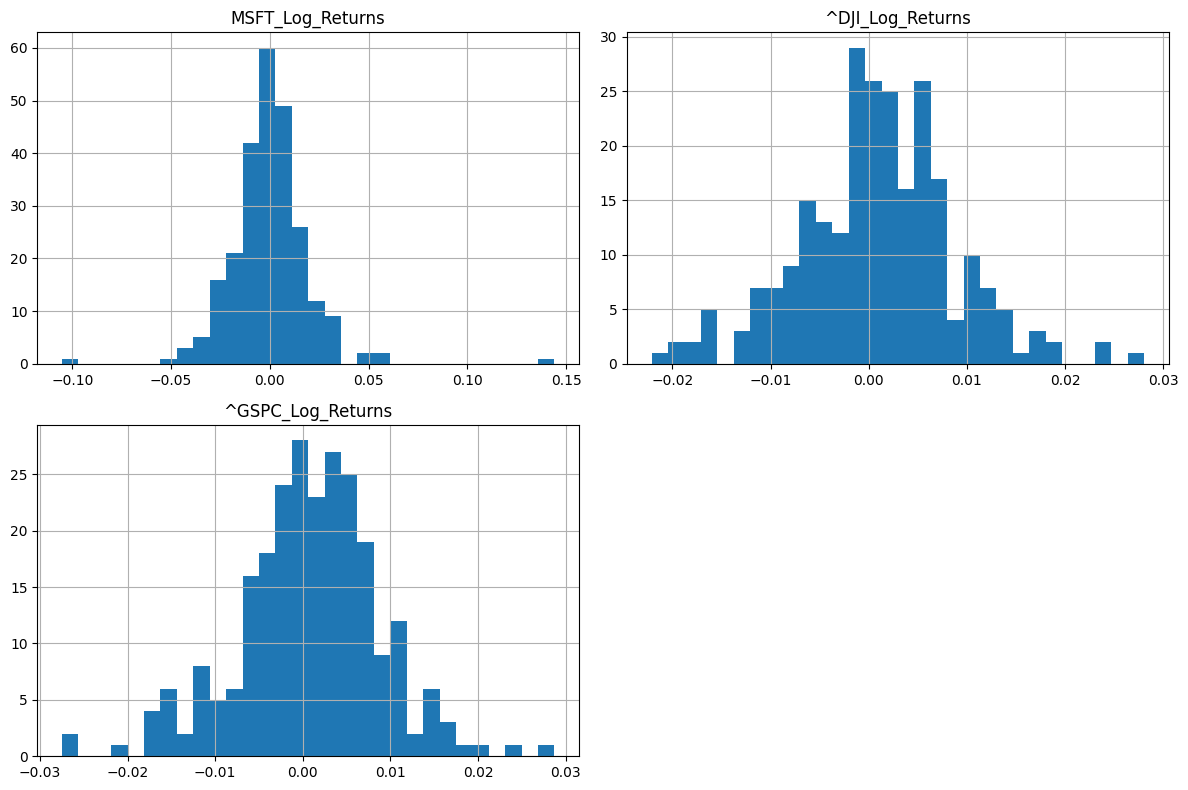

In [21]:
df[
    [
        "MSFT_Log_Returns",
        "^DJI_Log_Returns",
        "^GSPC_Log_Returns"
    ]
].hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()
plt.show()

In [22]:
df["MSFT_Positive"] = (
    df["MSFT_Log_Returns"] > 0
).astype(int)

In [23]:
print(df[[
    "MSFT_Log_Returns",
    "MSFT_Positive"
]].head(10))

   MSFT_Log_Returns  MSFT_Positive
0         -0.000517              0
1          0.014215              1
2         -0.016498              0
3          0.003643              1
4         -0.004431              0
5         -0.005919              0
6         -0.014277              0
7         -0.007977              0
8         -0.001288              0
9          0.005912              1


In [24]:
print(
    df["MSFT_Positive"].value_counts()
)

MSFT_Positive
0    126
1    124
Name: count, dtype: int64


In [25]:
print(
    df["MSFT_Positive"].mean()
)

0.496


In [26]:
corr = df[
    [
        "^DJI_Log_Returns",
        "^GSPC_Log_Returns"
    ]
].corr()

print(corr)

                   ^DJI_Log_Returns  ^GSPC_Log_Returns
^DJI_Log_Returns           1.000000           0.836014
^GSPC_Log_Returns          0.836014           1.000000


In [27]:
X_vif = df[
    [
        "^DJI_Log_Returns",
        "^GSPC_Log_Returns"
    ]
]

X_vif = sm.add_constant(X_vif)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

            Variable       VIF
0              const  1.010680
1   ^DJI_Log_Returns  3.321369
2  ^GSPC_Log_Returns  3.321369


In [28]:
X = df[
    [
        "^DJI_Log_Returns",
        "^GSPC_Log_Returns"
    ]
]

X = sm.add_constant(X)

y = df["MSFT_Positive"]

modelo_glm = sm.GLM(
    y,
    X,
    family=sm.families.Binomial(
        link=sm.families.links.Logit()
    )
)

resultado_glm = modelo_glm.fit()

print(resultado_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          MSFT_Positive   No. Observations:                  250
Model:                            GLM   Df Residuals:                      247
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -147.57
Date:                Sat, 15 Aug 2026   Deviance:                       295.14
Time:                        02:13:30   Pearson chi2:                     246.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1859
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.1454      0.14

In [29]:
df["DJI_pct"] = df["^DJI_Log_Returns"] * 100
df["GSPC_pct"] = df["^GSPC_Log_Returns"] * 100

In [30]:
X = df[
    [
        "DJI_pct",
        "GSPC_pct"
    ]
]

X = sm.add_constant(X)

modelo_glm_pct = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
)

resultado_pct = modelo_glm_pct.fit()

print(resultado_pct.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          MSFT_Positive   No. Observations:                  250
Model:                            GLM   Df Residuals:                      247
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -147.57
Date:                Sat, 15 Aug 2026   Deviance:                       295.14
Time:                        02:15:23   Pearson chi2:                     246.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1859
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1454      0.143     -1.019      0.3

In [31]:
odds_ratios = np.exp(
    resultado_glm.params
)

print(odds_ratios)

const                8.646968e-01
^DJI_Log_Returns     3.344512e+00
^GSPC_Log_Returns    4.520821e+59
dtype: float64


In [32]:
X = df[
    [
        "DJI_pct",
        "GSPC_pct"
    ]
]

X = sm.add_constant(X)

modelo = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
)

resultado = modelo.fit()

print(resultado.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          MSFT_Positive   No. Observations:                  250
Model:                            GLM   Df Residuals:                      247
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -147.57
Date:                Sat, 15 Aug 2026   Deviance:                       295.14
Time:                        02:16:48   Pearson chi2:                     246.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1859
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1454      0.143     -1.019      0.3

In [33]:
print("\nODDS RATIOS")
print(np.exp(resultado.params))


ODDS RATIOS
const       0.864697
DJI_pct     1.012146
GSPC_pct    3.949591
dtype: float64


In [34]:
df["Probabilidad"] = resultado.predict(X)

print(
    df[
        [
            "Date",
            "MSFT_Log_Returns",
            "MSFT_Positive",
            "Probabilidad"
        ]
    ].head(15)
)

         Date  MSFT_Log_Returns  MSFT_Positive  Probabilidad
0  2025-08-11         -0.000517              0      0.378653
1  2025-08-12          0.014215              1      0.804942
2  2025-08-13         -0.016498              0      0.576915
3  2025-08-14          0.003643              1      0.474012
4  2025-08-15         -0.004431              0      0.367497
5  2025-08-18         -0.005919              0      0.460050
6  2025-08-19         -0.014277              0      0.278455
7  2025-08-20         -0.007977              0      0.382401
8  2025-08-21         -0.001288              0      0.331677
9  2025-08-22          0.005912              1      0.875182
10 2025-08-25         -0.005873              0      0.322580
11 2025-08-26         -0.004412              0      0.604658
12 2025-08-27          0.009318              1      0.546507
13 2025-08-28          0.005707              1      0.571861
14 2025-08-29         -0.005805              0      0.263181


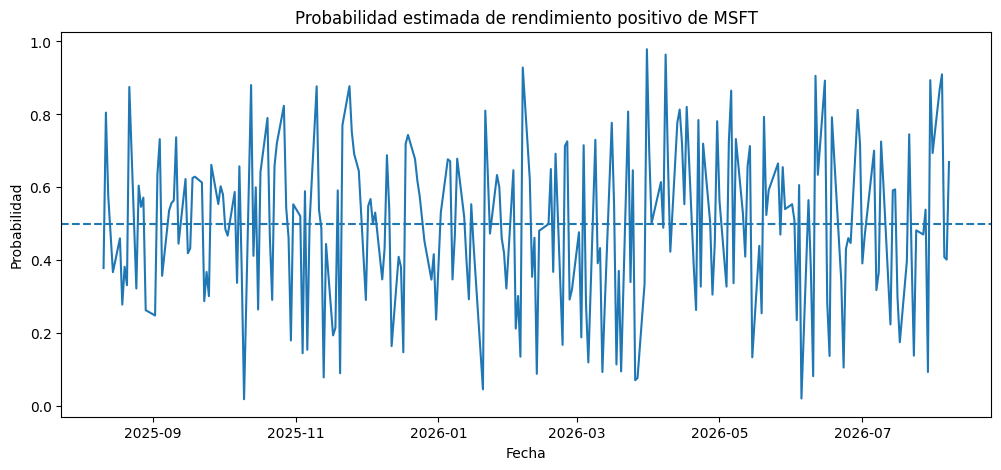

In [35]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Probabilidad"]
)

plt.axhline(
    0.5,
    linestyle="--"
)

plt.title(
    "Probabilidad estimada de rendimiento positivo de MSFT"
)

plt.xlabel("Fecha")
plt.ylabel("Probabilidad")

plt.show()

In [36]:
df["Prediccion"] = (
    df["Probabilidad"] >= 0.5
).astype(int)

In [37]:
print(
    pd.crosstab(
        df["MSFT_Positive"],
        df["Prediccion"],
        rownames=["Real"],
        colnames=["Predicción"]
    )
)

Predicción   0   1
Real              
0           85  41
1           39  85


In [38]:
cm = confusion_matrix(
    df["MSFT_Positive"],
    df["Prediccion"]
)

print(cm)

[[85 41]
 [39 85]]


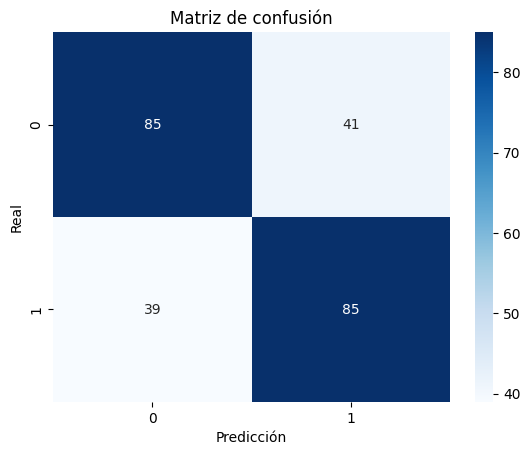

In [39]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")

plt.show()

In [40]:
accuracy = accuracy_score(
    df["MSFT_Positive"],
    df["Prediccion"]
)

print("Accuracy:", accuracy)

Accuracy: 0.68


In [41]:
auc = roc_auc_score(
    df["MSFT_Positive"],
    df["Probabilidad"]
)

print("ROC-AUC:", auc)

ROC-AUC: 0.7444956477214542


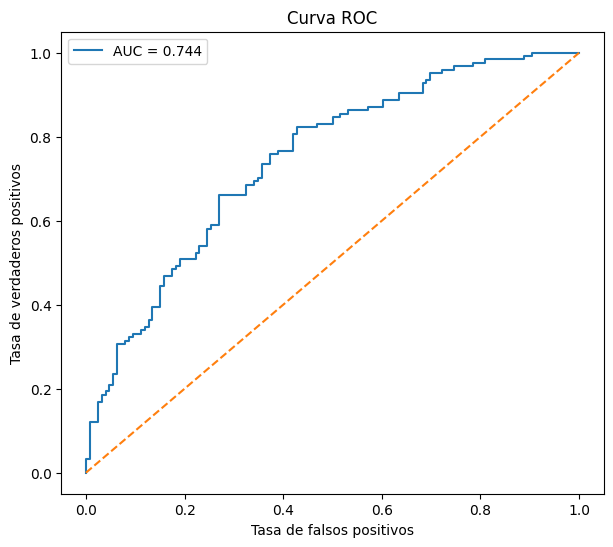

In [42]:
fpr, tpr, thresholds = roc_curve(
    df["MSFT_Positive"],
    df["Probabilidad"]
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

plt.title("Curva ROC")

plt.legend()

plt.show()

In [43]:
print(
    classification_report(
        df["MSFT_Positive"],
        df["Prediccion"]
    )
)

              precision    recall  f1-score   support

           0       0.69      0.67      0.68       126
           1       0.67      0.69      0.68       124

    accuracy                           0.68       250
   macro avg       0.68      0.68      0.68       250
weighted avg       0.68      0.68      0.68       250



In [44]:
print(
    "Deviance:",
    resultado.deviance
)

Deviance: 295.13833094341226


In [45]:
modelo_nulo = sm.GLM(
    y,
    np.ones((len(y), 1)),
    family=sm.families.Binomial()
).fit()

print(
    "Deviance modelo nulo:",
    modelo_nulo.deviance
)

Deviance modelo nulo: 346.5575901093016


In [47]:
print(
    "Pseudo R² McFadden:",
    1 - (resultado.llf / modelo_nulo.llf)
)

Pseudo R² McFadden: 0.14837147023579


In [48]:
n = len(y)

ll_modelo = resultado.llf
ll_nulo = modelo_nulo.llf

pseudo_r2_cs = 1 - np.exp(
    (2/n) * (ll_nulo - ll_modelo)
)

print(
    "Pseudo R² Cox-Snell:",
    pseudo_r2_cs
)

Pseudo R² Cox-Snell: 0.18590404302332764


In [49]:
print("AIC:", resultado.aic)

AIC: 301.13833094341226


In [50]:
LR = modelo_nulo.deviance - resultado.deviance

df_lr = resultado.df_model

p_value = stats.chi2.sf(
    LR,
    df_lr
)

print("LR:", LR)
print("gl:", df_lr)
print("p-value:", p_value)

LR: 51.41925916588934
gl: 2
p-value: 6.8304566649760525e-12


In [51]:
df["resid_deviance"] = (
    resultado.resid_deviance
)

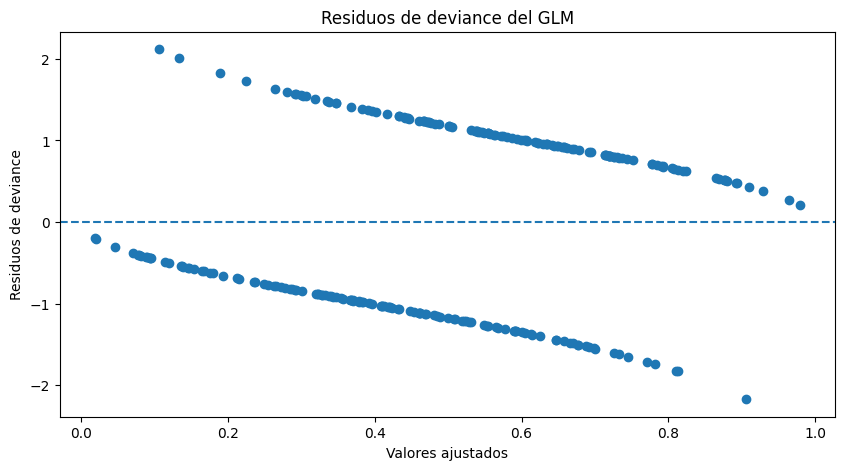

In [52]:
plt.figure(figsize=(10,5))

plt.scatter(
    resultado.fittedvalues,
    resultado.resid_deviance
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Valores ajustados")
plt.ylabel("Residuos de deviance")

plt.title(
    "Residuos de deviance del GLM"
)

plt.show()